<a href="https://colab.research.google.com/github/lovekurt82/lovekurt82.github.io/blob/master/population.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
file_path = '/230906.csv'
df = pd.read_csv(file_path)
df.head()

/tmp/ipykernel_329/2735503034.py:2: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,INPUT_DATE,LON,LAT,NDL,NUL,BAND,BW,PLMN,CELLID,RSRP,RSSI,RSCP,FDL,FUL,TYPE
0,2023-04-22 12:41,127.114622,37.331012,2850,20850,7.0,"20,10",45005.0,171,-102,-71,0,"26,302,665","25,102,545",LTE
1,2023-04-22 12:51,129.056747,35.132253,3743,21743,8.0,10,45008.0,30,-95,-64,0,954.3,909.3,LTE
2,2023-04-22 12:53,129.056747,35.132253,3743,21743,8.0,10,45008.0,30,-96,-65,0,954.3,909.3,LTE
3,2023-04-22 13:00,129.014889,35.370014,2500,20500,5.0,10,45005.0,228,-103,-72,0,879,834,LTE
4,2023-04-22 13:01,128.635657,35.922770,275,18275,1.0,20,45005.0,92,-92,-61,0,2137.5,1947.5,LTE


In [20]:
df = df.rename(columns={
    'LON': 'x',
    'LAT': 'y'
})

df.head()

,INPUT_DATE,x,y,NDL,NUL,BAND,BW,PLMN,CELLID,RSRP,RSSI,RSCP,FDL,FUL,TYPE
0,2023-04-22 12:41,127.114622,37.331012,2850,20850,7.0,"20,10",45005.0,171,-102,-71,0,"26,302,665","25,102,545",LTE
1,2023-04-22 12:51,129.056747,35.132253,3743,21743,8.0,10,45008.0,30,-95,-64,0,954.3,909.3,LTE
2,2023-04-22 12:53,129.056747,35.132253,3743,21743,8.0,10,45008.0,30,-96,-65,0,954.3,909.3,LTE
3,2023-04-22 13:00,129.014889,35.370014,2500,20500,5.0,10,45005.0,228,-103,-72,0,879,834,LTE
4,2023-04-22 13:01,128.635657,35.922770,275,18275,1.0,20,45005.0,92,-92,-61,0,2137.5,1947.5,LTE


In [22]:
# 2. GeoDataFrame 변환
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.x, df.y),
    crs="EPSG:4326"
)


In [24]:
# 3. 투영좌표계 변환 (UTM-K 예시)
gdf = gdf.to_crs(epsg=5179)


In [26]:
# 4. 좌표 배열 생성
coords = np.vstack([gdf.geometry.x, gdf.geometry.y]).T


In [29]:
# 5. KDE 모델 생성
kde = KernelDensity(
    bandwidth=50,      # 탐색반경 (m)
    kernel='gaussian'
)

# Check for infinite or NaN values in coords and filter them out
if not np.all(np.isfinite(coords)):
    # Filter out rows with non-finite values
    finite_coords = coords[np.all(np.isfinite(coords), axis=1)]
    print(f"Warning: Removed {len(coords) - len(finite_coords)} rows with non-finite coordinates.")
    coords = finite_coords

kde.fit(coords)

KernelDensity(bandwidth=50)

In [33]:
# 6. 격자 생성
xmin, ymin = np.min(coords, axis=0)
xmax, ymax = np.max(coords, axis=0)
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
grid_coords = np.vstack([xx.ravel(), yy.ravel()]).T

In [35]:
# 7. 밀도 계산
z = np.exp(kde.score_samples(grid_coords))
z = z.reshape(xx.shape)

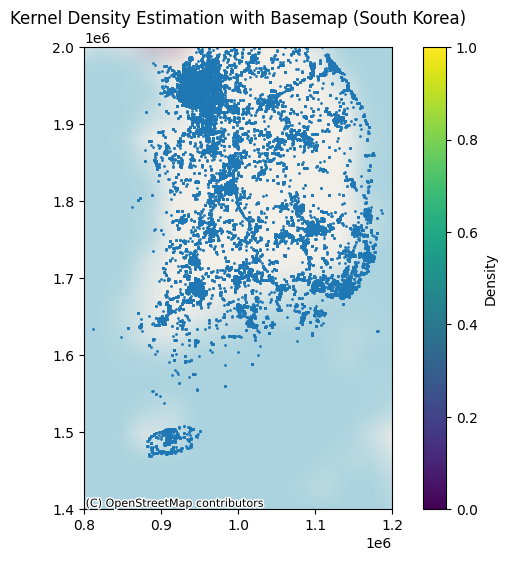

In [42]:
!pip install contextily
import contextily as ctx

# 8. 시각화
plt.figure(figsize=(8,6))

# Define South Korea's bounding box in EPSG:5179 (approximate values)
south_korea_xmin = 800000
south_korea_ymin = 1400000
south_korea_xmax = 1200000
south_korea_ymax = 2000000

plt.imshow(z.T, origin='lower',
           extent=[xmin, xmax, ymin, ymax])
plt.scatter(gdf.geometry.x, gdf.geometry.y, s=1)
plt.colorbar(label="Density")

ax = plt.gca()
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=gdf.crs)

# Apply the South Korea bounds to the plot
ax.set_xlim(south_korea_xmin, south_korea_xmax)
ax.set_ylim(south_korea_ymin, south_korea_ymax)

plt.title("Kernel Density Estimation with Basemap (South Korea)")
plt.show()